In [19]:
from tripodpy import Simulation
import matplotlib.pyplot as plt
import dustpy.constants as c
import numpy as np

In [2]:
sim = Simulation()

In [3]:
sim.ini

namespace(dust=namespace(aIniMax=0.0001,
                         allowDriftingParticles=False,
                         d2gRatio=0.01,
                         distExp=-3.5,
                         rhoMonomer=1.67,
                         vFrag=100.0),
          gas=namespace(alpha=0.001,
                        Mdisk=9.942049353490256e+31,
                        mu=3.847030424486999e-24,
                        SigmaExp=-1.0,
                        SigmaRc=897587224200000.0),
          grid=namespace(mmin=1e-12,
                         Nr=100,
                         rmin=14959787070000.0,
                         rmax=1.495978707e+16),
          star=namespace(M=1.988409870698051e+33, R=139140000000.0, T=5772.0))

In [4]:
sim.initialize()

In [5]:
sim.toc

tripodpy
    - components: Group (components)
        - Default: Group (Default gas componentDefault (dust_tracer=False, gas_active=True, gas_tracer=False))
            - boundary: Group (Boundary conditions for component)
            - dust: Group (Dust related fields)
                - Fi: Field (Gas flux [g/cm²/s])
                - pars: Group (Dust parameters)
                    - rhos: Field (Material density of dust grains [g/cm³])
                - S: Group (Gas source terms)
                    - coag: Field (Hydrodynamical source term [g/cm²/s])
                    - ext: Field (External source term [g/cm²/s])
                    - hyd: Field (Hydrodynamical source term [g/cm²/s])
                    - tot: Field (Total source term [g/cm²/s])
                - S_Sigma: Field (Source term for dust surface density [g/cm²])
                - Sigma: Field (Dust surface density [g/cm²])
                - Sigma_dot: Field (Gas surface density source term [g/cm²/s])
               

In [22]:
sim.run() 


tripodpy v1.0.0

Creating data directory data.
Writing file data/data0000.hdf5
Writing dump file data/frame.dmp
Writing file data/data0001.hdf5
Writing dump file data/frame.dmp
Writing file data/data0002.hdf5
Writing dump file data/frame.dmp
Writing file data/data0003.hdf5
Writing dump file data/frame.dmp
Writing file data/data0004.hdf5
Writing dump file data/frame.dmp
Writing file data/data0005.hdf5
Writing dump file data/frame.dmp
Writing file data/data0006.hdf5
Writing dump file data/frame.dmp
Writing file data/data0007.hdf5
Writing dump file data/frame.dmp
Writing file data/data0008.hdf5
Writing dump file data/frame.dmp
Writing file data/data0009.hdf5
Writing dump file data/frame.dmp
Writing file data/data0010.hdf5
Writing dump file data/frame.dmp
Writing file data/data0011.hdf5
Writing dump file data/frame.dmp
Writing file data/data0012.hdf5
Writing dump file data/frame.dmp
Writing file data/data0013.hdf5
Writing dump file data/frame.dmp
Writing file data/data0014.hdf5
Writing du

In [6]:
from tripodpy import plot
import dustpy.constants as c

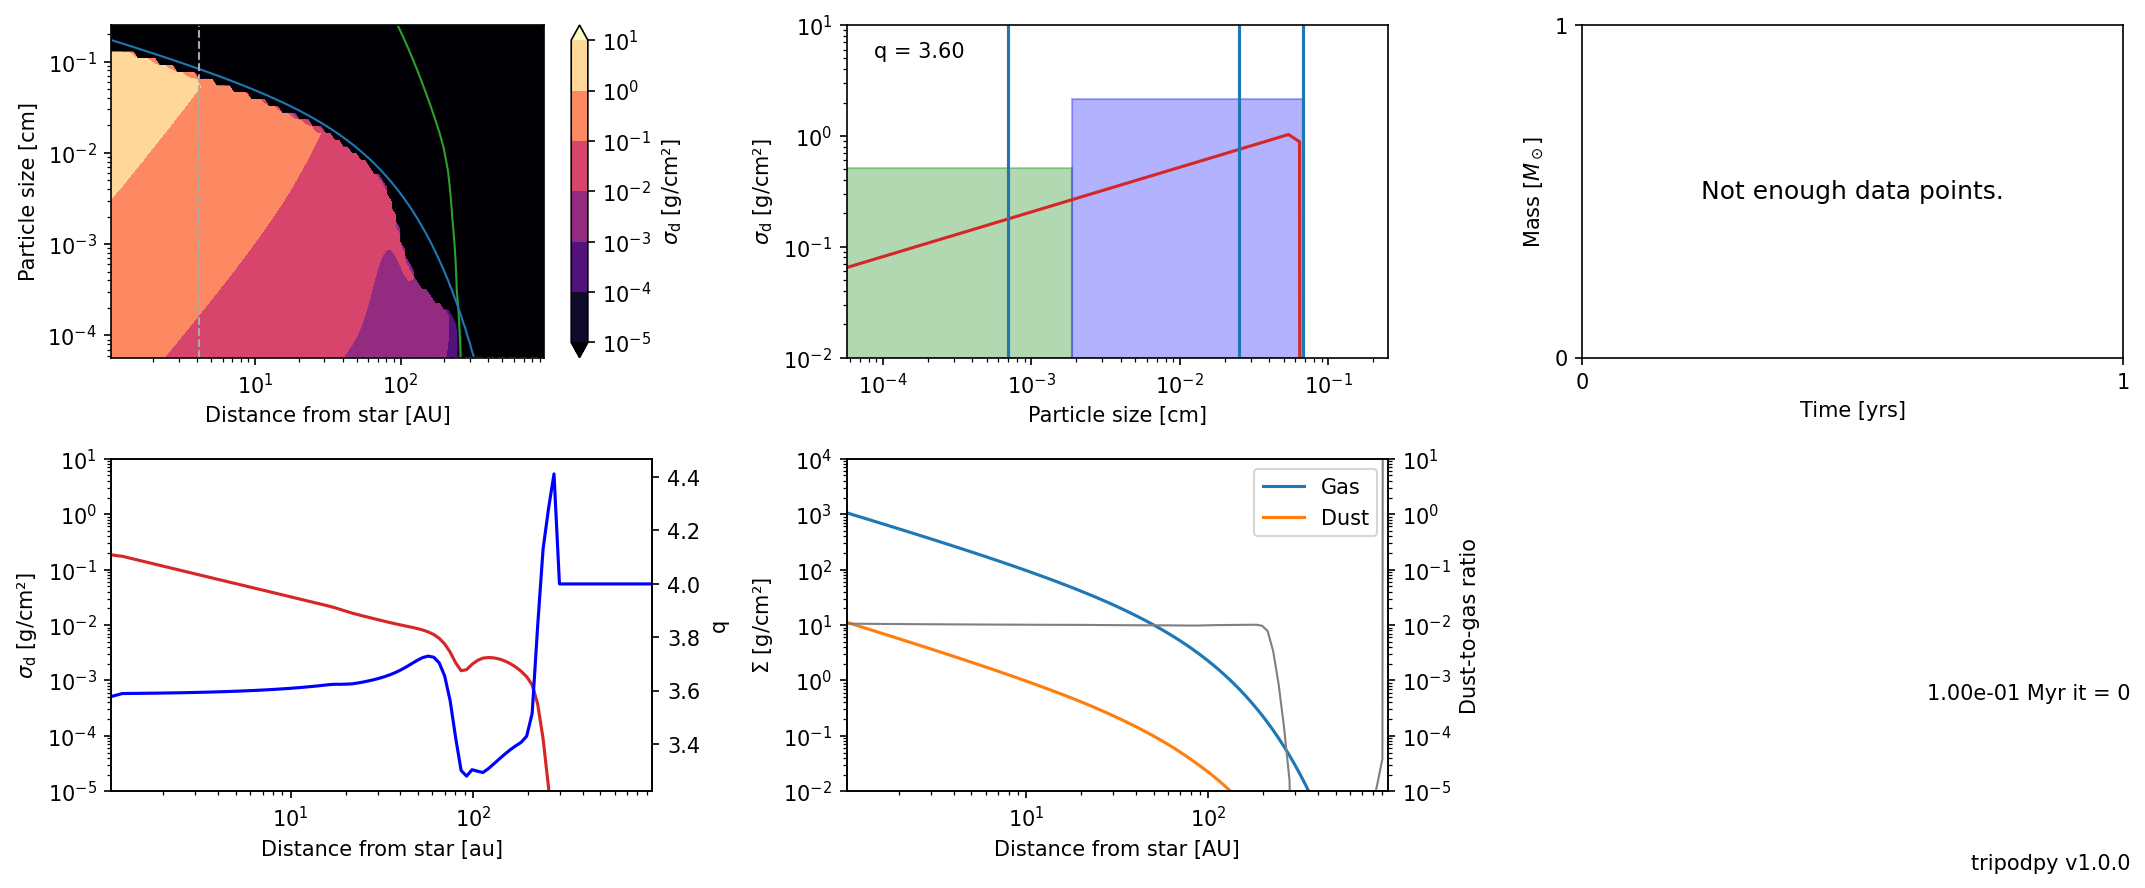

In [7]:
plot.panel(sim,show_limits=True,ir=20)


# Local Size Distribution
### what variables in the code represent wich part of the model
![alt text](size_dist.png "Title") 

## How do I get a dustpy-like size distribution?

In [ ]:
from tripodpy.utils import sim_size_distribution,get_size_distribution

In [44]:
a,a_i,sig_da = sim_size_distribution(sim)
#Alternatively, you can directly call get_size_distribution with the appropriate parameters:
#a,a_i,sig_da = get_size_distribution(sim.dust.Sigma.sum(-1),sim.dust.s.max,q=-sim.dust.qrec,na=100)

Text(0, 0.5, 'Particle size [cm]')

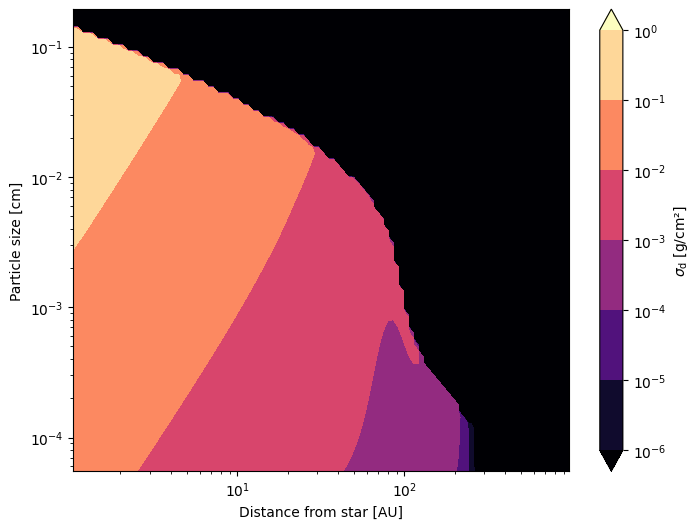

In [45]:
from operator import le


plt.figure(figsize=(8,6))

sd_max = np.ceil(np.log10(sig_da.max()))
levels = np.linspace(sd_max-6, sd_max, 7)

plt00 = plt.contourf(sim.grid.r[...]/c.au,
                          a,
                          np.log10(sig_da[...].T),
                          cmap="magma",
                          extend="both",
                          levels = levels
                          )
plt.yscale('log')
plt.xscale('log')
ax00 = plt.gca()
cbar00 = plt.colorbar(plt00, ax=ax00)
cbar00.ax.set_ylabel(r"$\sigma_\mathrm{d}$ [g/cm²]")
cbar00ticklabels = []
for i in levels:
    cbar00ticklabels.append("$10^{{{:d}}}$".format(int(i)))
cbar00.ax.set_yticklabels(cbar00ticklabels)
ax00.set_xlim(sim.grid.r[ 0]/c.au, sim.grid.r[-1]/c.au)
ax00.set_xscale("log")
ax00.set_yscale("log")
ax00.set_xlabel("Distance from star [AU]")
ax00.set_ylabel("Particle size [cm]")